In [1]:
import os
import torch
from torch.utils.data import Dataset
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt


In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [3]:
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

data_dir = "oxfordflowers102/split"

train_dataset = datasets.ImageFolder(os.path.join(data_dir, 'train'), transform=data_transforms)
val_dataset = datasets.ImageFolder(os.path.join(data_dir, 'val'), transform=data_transforms)
test_dataset = datasets.ImageFolder(os.path.join(data_dir, 'test'), transform=data_transforms)

# train_dataset, val_dataset, test_dataset 

In [33]:
class_numbers = train_dataset.classes
# class_numbers

In [36]:
class_to_idx = train_dataset.class_to_idx
# class_to_idx

In [5]:
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [6]:
import torchvision.models as models

model = models.resnet18(pretrained=True)

c:\Users\kompo\Desktop\PyTorch\.venv\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\kompo\Desktop\PyTorch\.venv\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [7]:
import torch.nn as nn

num_classes = len(train_dataset.classes)
model.fc = nn.Linear(model.fc.in_features, num_classes)

In [8]:
for param in model.parameters():
    param.requires_grad = False  # Freeze all layers

for param in model.fc.parameters():
    param.requires_grad = True  # Only train the classifier

In [9]:
from helper_functions import accuracy_fn

In [10]:
def train_step(model: torch.nn.Module, dataloader:torch.utils.data.DataLoader, loss_fn: torch.nn.Module, optimizer: torch.optim.Optimizer, device=device):
  model.train()

  train_loss, train_acc = 0, 0

  for batch, (X, y) in enumerate(dataloader):
    X, y = X.to(device), y.to(device)

    y_pred = model(X)

    loss = loss_fn(y_pred, y)
    train_loss += loss.item()

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
    # train_acc += (y_pred_class == y).sum().item()/len(y_pred)
    train_acc += accuracy_fn(y_true=y, y_pred=y_pred_class)

  train_loss = train_loss / len(dataloader)
  train_acc = train_acc / len(dataloader)

  return train_loss, train_acc

In [11]:
def test_step(model: torch.nn.Module, dataloader: torch.utils.data.DataLoader, loss_fn: torch.nn.Module, device=device):
  model.eval()

  test_loss, test_acc = 0, 0

  with torch.inference_mode():
    for batch, (X, y) in enumerate(dataloader):
      X, y = X.to(device), y.to(device)

      test_pred_logits = model(X)

      loss = loss_fn(test_pred_logits, y)
      test_loss += loss.item()

      test_pred_labels = test_pred_logits.argmax(dim=1)
      # test_acc += ((test_pred_labels == y).sum().item()/len(test_pred_labels))
      test_acc += accuracy_fn(y_true=y, y_pred=test_pred_labels)

  test_loss = test_loss / len(dataloader)
  test_acc = test_acc / len(dataloader)

  return test_loss, test_acc

In [12]:
from tqdm.auto import tqdm

def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 5,
          device: torch.device = device):

  results = {"train_loss": [],
             "train_acc": [],
             "test_loss": [],
             "test_acc": []}

  model.to(device)

  for epoch in tqdm(range(epochs)):
    train_loss, train_acc = train_step(model=model,
                                        dataloader=train_dataloader,
                                        loss_fn=loss_fn,
                                        optimizer=optimizer,
                                        device=device)
    test_loss, test_acc = test_step(model=model,
                                    dataloader=test_dataloader,
                                    loss_fn=loss_fn,
                                    device=device)

    print(
        f"Epoch: {epoch+1} | "
        f"train_loss: {train_loss:.4f} | "
        f"train_acc: {train_acc: 4f} | "
        f"test_acc: {test_acc:.4f} | "
        f"test_loss: {test_loss:.4f}"
    )

    results["test_loss"].append(test_loss)
    results["test_acc"].append(test_acc)
    results["train_loss"].append(train_loss)
    results["train_acc"].append(train_acc)

  return results

c:\Users\kompo\Desktop\PyTorch\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [13]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

In [14]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

EPOCHS = 5

from timeit import default_timer as timer
start_time = timer()

results = train(model=model,
                train_dataloader=train_loader,
                test_dataloader=test_loader,
                optimizer=optimizer,
                loss_fn=criterion,
                epochs=EPOCHS,
                device=device)

end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

 20%|██        | 1/5 [01:04<04:19, 64.77s/it]

Epoch: 1 | train_loss: 4.5920 | train_acc:  7.101004 | test_acc: 19.2034 | test_loss: 3.8553


 40%|████      | 2/5 [02:06<03:09, 63.19s/it]

Epoch: 2 | train_loss: 3.2057 | train_acc:  41.866629 | test_acc: 48.7532 | test_loss: 2.9935


 60%|██████    | 3/5 [03:06<02:03, 61.61s/it]

Epoch: 3 | train_loss: 2.2541 | train_acc:  73.953683 | test_acc: 62.4352 | test_loss: 2.3855


 80%|████████  | 4/5 [04:06<01:01, 61.11s/it]

Epoch: 4 | train_loss: 1.6037 | train_acc:  87.834821 | test_acc: 68.2804 | test_loss: 1.9785


100%|██████████| 5/5 [05:06<00:00, 61.22s/it]

Epoch: 5 | train_loss: 1.1549 | train_acc:  92.717634 | test_acc: 72.6198 | test_loss: 1.7217
Total training time: 306.318 seconds


In [15]:
PATH = './models/oxford_resnet.pth'
torch.save(model.state_dict(), PATH)

In [16]:
from helper_functions import plot_loss_curves

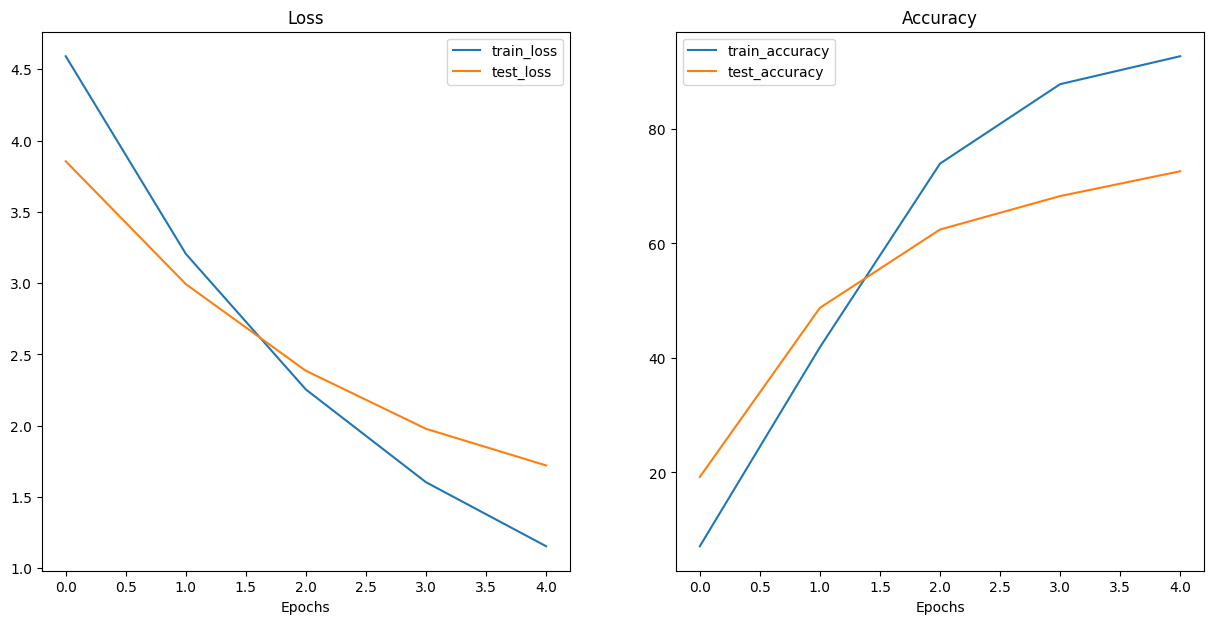

In [17]:
plot_loss_curves(results)

In [18]:
def make_predictions(model: torch.nn.Module, data: list, device: torch.device = device):
  pred_probs = []
  model.to(device)
  model.eval()
  with torch.inference_mode():
    for sample in data:

      sample = torch.unsqueeze(sample, dim=0).to(device)

      pred_logit = model(sample)
      pred_prob = torch.softmax(pred_logit.squeeze(), dim=0)
      pred_probs.append(pred_prob.cpu())

  pred_probs = torch.stack(pred_probs)

  return pred_probs

In [ ]:
y_preds = []

model.eval()
with torch.inference_mode():
  for X, y in tqdm(test_loader, desc="making predictions"):
    X, y = X.to(device), y.to(device)
    y_logit = model(X)
    y_pred = torch.softmax(y_logit.squeeze(), dim=0).argmax(dim=1)
    y_preds.append(y_pred.cpu())

# print(y_preds)
y_pred_tensor  = torch.cat(y_preds)
y_pred_tensor[:10]

making predictions: 100%|██████████| 193/193 [00:55<00:00,  3.50it/s]

[tensor([97, 38, 38, 29,  0, 62, 37, 67, 80, 94, 28, 92, 75, 22, 71, 61, 97, 24,
        87, 86, 84, 45, 17,  9, 47,  1,  4, 78, 44, 57,  1,  1]), tensor([101,  79,  64,  47,  13,  91,  77,  47,   4,  52,   7,   8,  10,  62,
         17,  94,  28,   9,   4,   1,  33,  60,   1, 100,   1,  47,  86,  45,
          8,   3,  55,  31]), tensor([27, 57, 44, 76, 61, 51, 13, 16, 78, 59, 89, 67, 88,  9,  4, 16, 63, 39,
        58,  1, 24, 85, 55, 15,  3, 35,  5, 55, 85, 60, 71, 13]), tensor([ 28,  24,  27,  61, 100,  31,  44,   9,  38,  83,  94,  10,  99,  35,
         63,  53,  71,   2,  55,  16,   4,  67,  92,  60,  45,  20,  62,   7,
         50,  59,  21,  20]), tensor([ 93,  45,   7,   0,  73,  40,  56,  87,  74,  24,  49,  59,  58,   9,
         35,  55,  42,  41,  13,  10,  93,  47,  55,  32,  32,  39,  53,   3,
          3,  55,  83, 100]), tensor([55, 83, 20,  3, 14, 46, 11, 84, 21, 16, 62, 68, 84, 56, 64, 47, 47, 32,
        54, 33, 80, 95, 24, 63, 67, 80, 24, 98, 74,  1, 56,  0]), ten

tensor([97, 38, 38, 29,  0, 62, 37, 67, 80, 94])

In [20]:
# print(y_preds)
y_pred_tensor[:10]

tensor([97, 38, 38, 29,  0, 62, 37, 67, 80, 94])

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [22]:
def get_all_preds(model, dataloader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.inference_mode():
        for inputs, labels in tqdm(dataloader, desc="Getting all predictions"):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_preds), np.array(all_labels)

# Get predictions and labels
y_pred, y_true = get_all_preds(model, test_loader)

Getting all predictions: 100%|██████████| 193/193 [00:54<00:00,  3.57it/s]


In [29]:
import json

with open('cat_to_name.json', 'r') as f:
    class_names = json.load(f)

In [49]:
# Convert from 1-based to 0-based indexing to match PyTorch's ImageFolder
class_names_zero_indexed = {i - 1: name for i, name in class_names.items()}

# Generate display labels for the confusion matrix
display_labels = [class_names_zero_indexed[i] for i in range(102)]

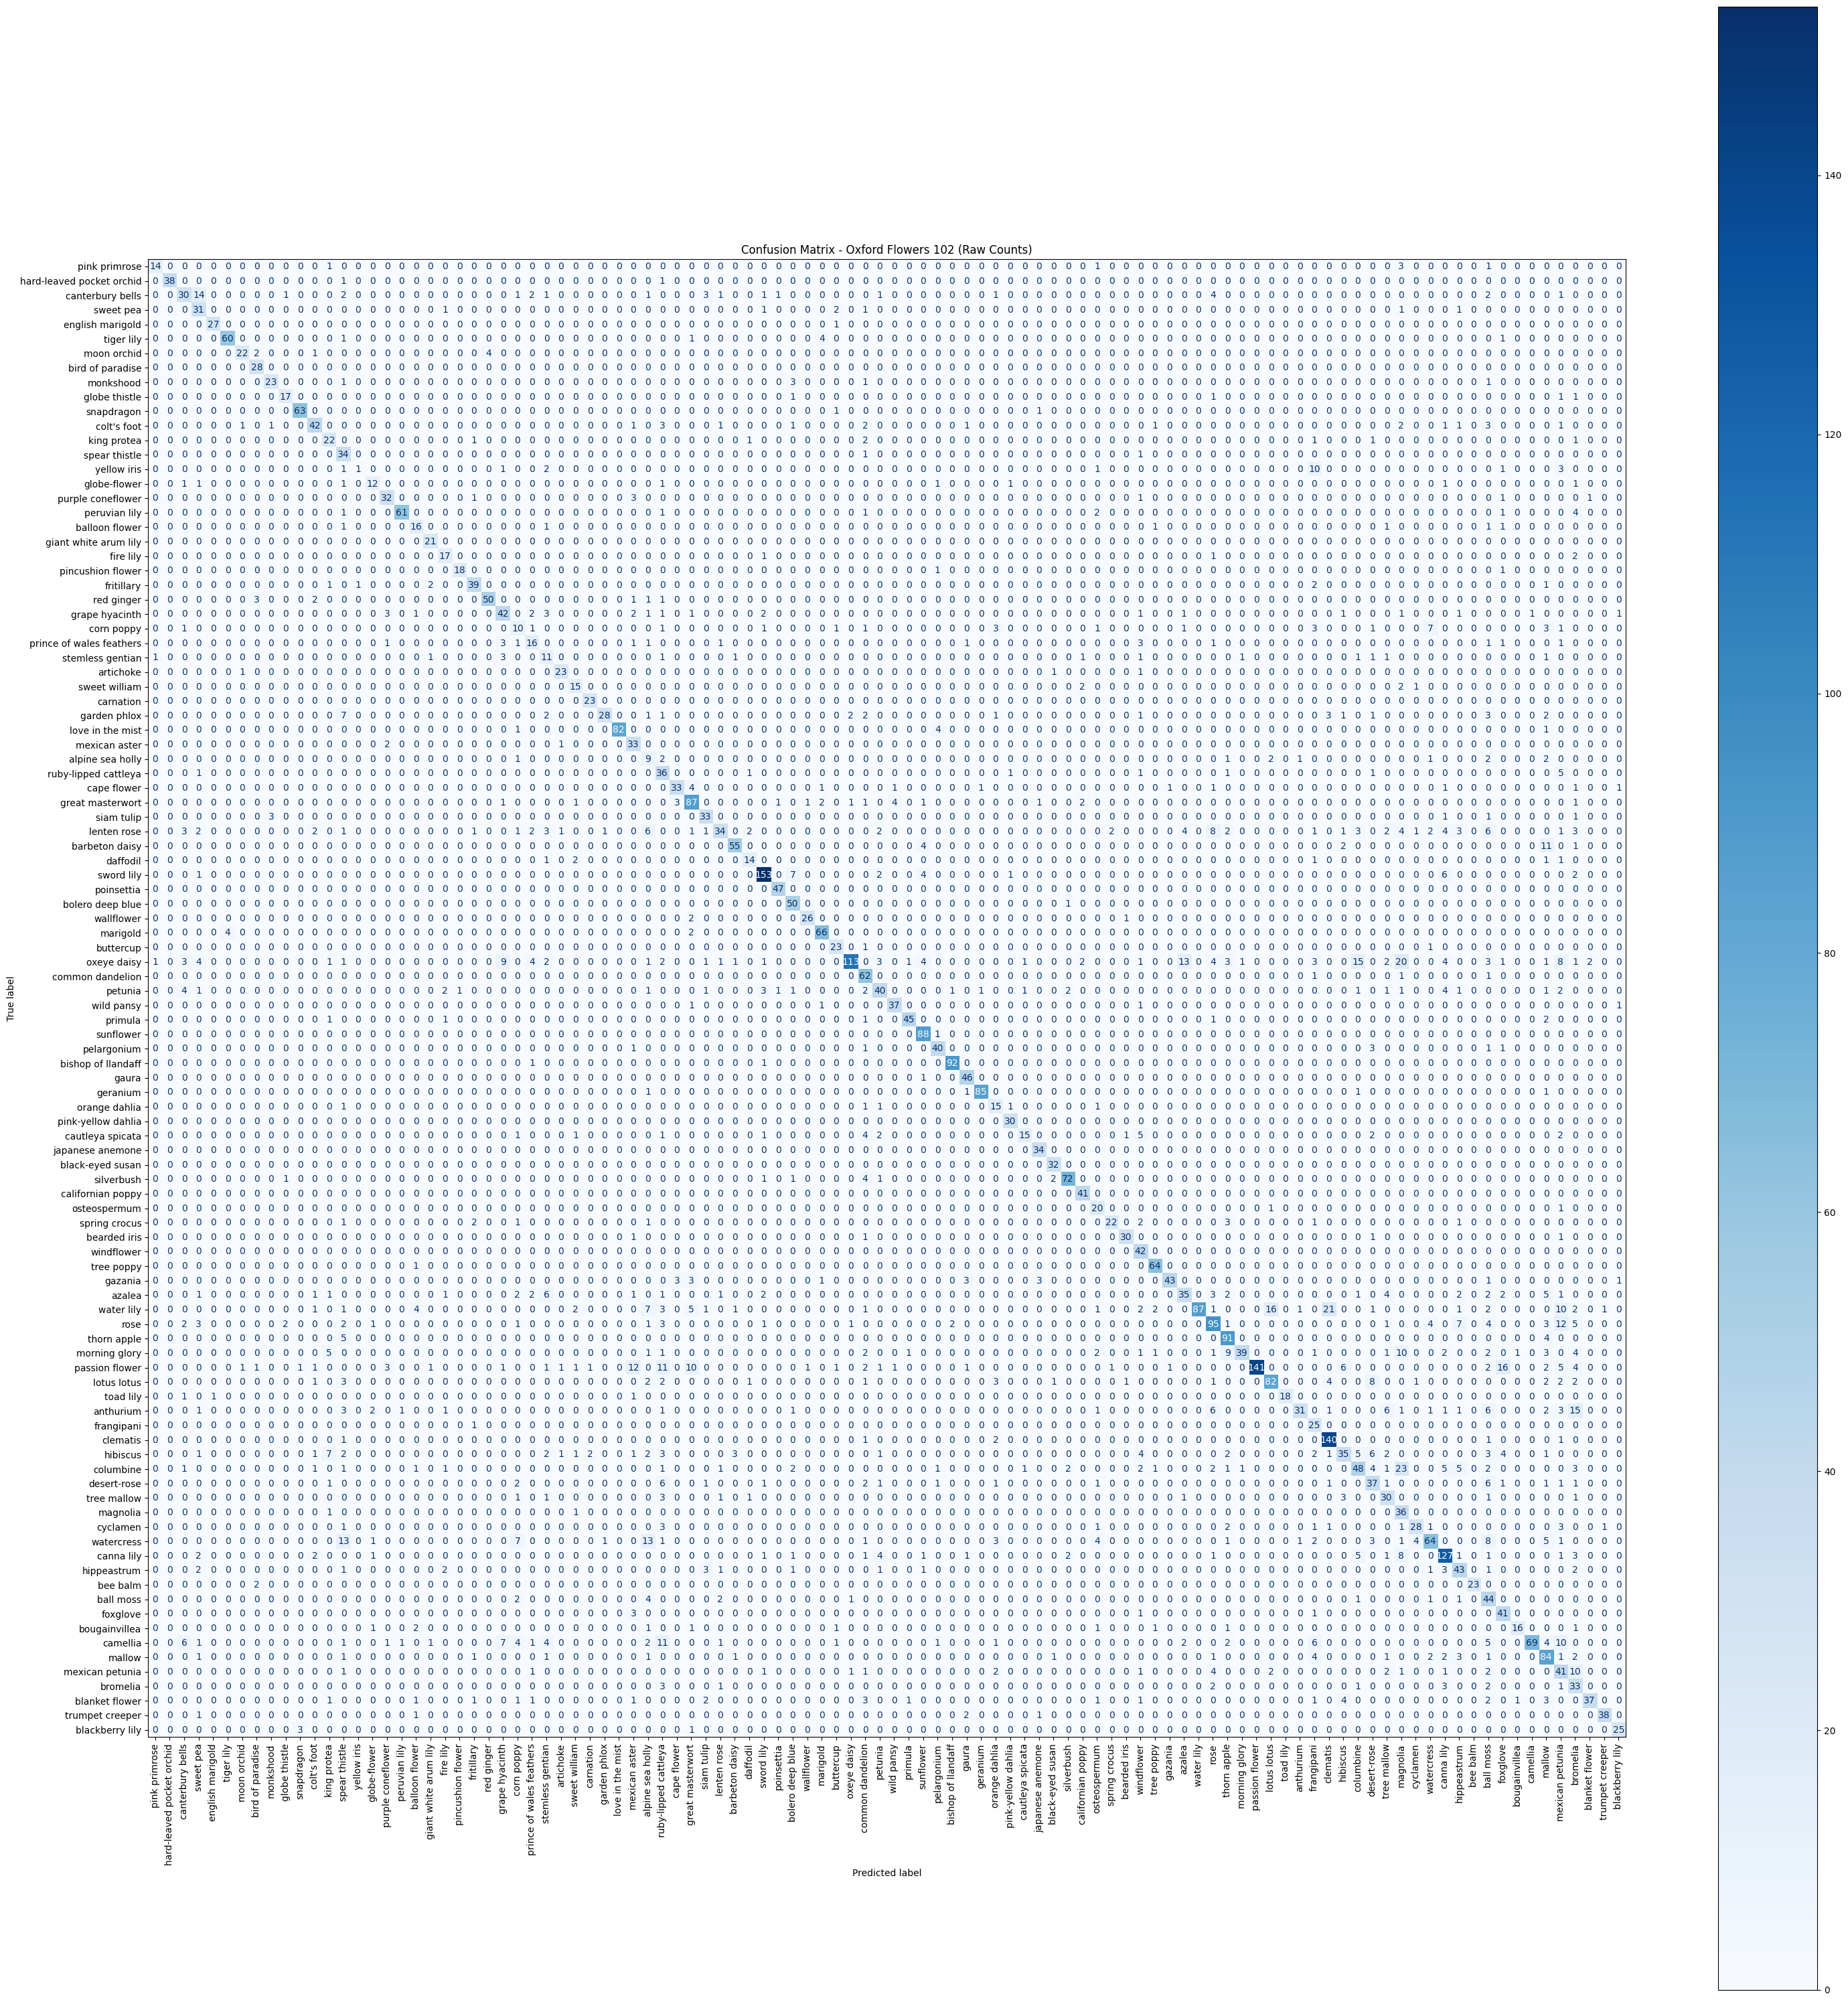

In [ ]:
cm = confusion_matrix(y_true, y_pred)  # Raw counts, not normalized

# Plot the confusion matrix
fig, ax = plt.subplots(figsize=(30, 30))  # Increase size for 102 labels
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
# disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=test_dataset.classes)
disp.plot(ax=ax, xticks_rotation='vertical', cmap="Blues")
# disp.plot(ax=ax, xticks_rotation=90, cmap="viridis")
plt.title("Confusion Matrix - Oxford Flowers 102 ")
plt.tight_layout()
plt.show()